# Set the Working Directory 
Always set the current working directory to the root of the repo so you can import the helper functions 

In [2]:
import os
# Change to the directory where the script is located to be able to import local modules
os.chdir("..")

In [18]:
from pathlib import Path
cwd = Path.cwd()
print(cwd)

h:\My Drive\Courses\MasterThesis\Code\NonLinear_FEMSM


# Libraries 

In [19]:
from utils.checkpoints import load_checkpoint
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
from utils.checkpoints import load_checkpoint, latest_checkpoint_path, train_dir, make_train_id
from utils.runs import load_by_params


In [20]:
df = pd.read_parquet(cwd/"results"/"index"/"training.parquet")
df.head()

,model,train_id,data_run_id,path,created_at,git_commit,cfg_latent_dim,cfg_num_inducing,cfg_num_inducing_hidden,cfg_treatment_lag,cfg_optimize_hyperparams,metrics_json,final_loss
0,seqgplvm,c56c2127c9,4d861a18,results\models\seqgplvm\c56c2127c9,2025-09-22T20:32:53Z,d5e5e85,1,50,5,1,0.01,"{""final_loss"":13.194746971130371,""epochs_compl...",13.194747


In [27]:
### DATA CONFIG
dgp = "blackwell_yamauchi"
n = 500
T = 20
seed = 1 
a = 1.0
p = 2 

beta_dict = {2:  [-0.5, -0.5], 4: [-0.5, -0.5, 1.0, -0.5]}
gamma_dict = {2: [1.0, 0.5], 4: [1.0, 0.5, 1.0, 1.0]}

params = {
    "phi": 0.3,
    "tau_F": 1.0, 
    "tau_C": 0.3,
    "mean_x": -0.5, 
    "offdiag": 0.2,
    "sigma_eps": 1.0, 
    "max_lag_x": 0, 
    "max_lag_d": 3,
    "split_seed": 42
    }


treatment_model = "logit"

params["treatment_model"] = treatment_model

cfg = {"dgp": dgp, "n": n, "T": T, "seed": seed, "a": a, "p": p,
       "beta": beta_dict[p], "gamma": gamma_dict[p], **params}
df, df_manifest = load_by_params(".", cfg)

### MODEL CONFIG
data_run_id = df_manifest.get("run_id") 
model_name = "seqgplvm"
device = "cuda"
_train_cfg_identity = {
        "latent_dim": 1,
        "num_inducing": 50,
        "num_inducing_hidden": 5,
        "treatment_lag": 1,
        "optimize_hyperparams": 1e-2,
    }

train_id = make_train_id(
        data_run_id=data_run_id,
        model_name=model_name,
        train_cfg=_train_cfg_identity,
    )
train_out = train_dir(".", "seqgplvm", train_id)
ckpt_path = latest_checkpoint_path(train_out)
payload = load_checkpoint(ckpt_path, map_location=device)
manifest = json.loads((train_out / "manifest.json").read_text(encoding="utf-8"))
config = json.loads((train_out / "config.json").read_text(encoding="utf-8"))

extra = payload.get("extra")
loss_list     = extra.get("loss_list")
param_hist    = extra.get("param_hist")
actual_params = extra.get("actual_params")

step = config["logging"]["param_logging_freq"]

h:\My Drive\Courses\MasterThesis\Code\NonLinear_FEMSM\utils\checkpoints.py:192: FutureWarning:

You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.



# Loss 

In [39]:
np.arange(len(loss_list)) * step

array([ 0, 10, 20, 30, 40, 50, 60, 70, 80, 90])

In [38]:
np.arange(len(loss_list))

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])

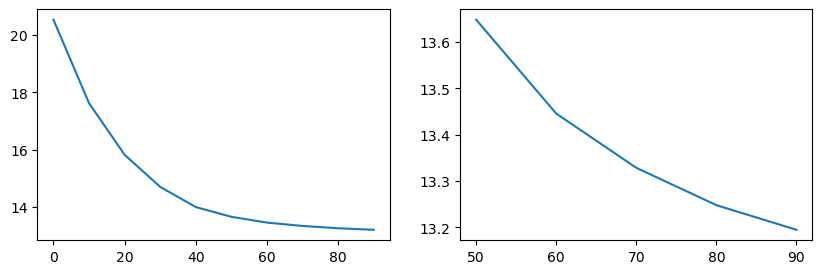

In [46]:
import matplotlib.pyplot as plt

last_n_step = 5
fig,ax = plt.subplots(1,2,figsize = (10,3))
ax[0].plot(np.arange(len(loss_list)) * step, loss_list)
ax[1].plot(range((len(loss_list)- last_n_step) * step, len(loss_list) * step, step) ,loss_list[-last_n_step:])
plt.show()

In [45]:
manifest

{'model': 'seqgplvm',
 'train_id': 'c56c2127c9',
 'created_at': '2025-09-22T20:32:53Z',
 'git_commit': 'd5e5e85',
 'python': '3.12.3',
 'node': 'Ali-Setareh',
 'data_ref': {'dgp': 'blackwell_yamauchi',
  'data_file': 'data\\raw\\blackwell_yamauchi\\4d861a18',
  'split_file': 'data\\splits\\blackwell_yamauchi\\N500_T20_p2_splitseed42.json',
  'data_run_id': '4d861a18'},
 'status': 'success',
 'epochs_completed': 100,
 'last_updated': '2025-09-22T20:33:31Z'}

# Params

In [23]:
params = set([item.split(".")[-1] for item in param_hist.keys()])
params

{'inducing_points',
 'q_log_sigma',
 'q_mu',
 'raw_constant',
 'raw_lengthscale',
 'raw_outputscale'}

In [25]:
from utils.inspectors import plot_param_history

key = "Z.q_mu"
fig = plot_param_history(param_hist = param_hist, key= key, ls_num=2, x_start= 0, x_step=config["logging"]["param_logging_freq"])
fig

yes


FigureWidget({
    'data': [{'mode': 'lines',
              'name': 'Z.q_mu_0',
              'type': 'scatter',
              'uid': 'ed7054c1-890c-451e-8ef2-39a969d1654e',
              'x': {'bdata': ('AAAKABQAHgAoADIAPABGAFAAWgBkAG' ... '1IDVINXA1mDXANeg2EDY4NmA2iDQ=='),
                    'dtype': 'i2'},
              'y': {'bdata': 'hsiAPj61rz7o3OY+2zUQP5exKz8H2EM/DbVWPySKZD82Z20/k6BzPw==', 'dtype': 'f4'}},
             {'mode': 'lines',
              'name': 'Z.q_mu_1',
              'type': 'scatter',
              'uid': 'a2a7e72e-670a-4dea-a7c3-985a5ef72090',
              'x': {'bdata': ('AAAKABQAHgAoADIAPABGAFAAWgBkAG' ... '1IDVINXA1mDXANeg2EDY4NmA2iDQ=='),
                    'dtype': 'i2'},
              'y': {'bdata': 'cVQpwMG7JMA9Ux/AmycYwChGEMDEDAjAjRQAwHS58L8nmuK/bLfVvw==', 'dtype': 'f4'}},
             {'mode': 'lines',
              'name': 'Z.q_mu_2',
              'type': 'scatter',
              'uid': '58e3f76c-c127-4752-a2d5-54684387926d',
              'x': {

In [16]:
manifest

{'model': 'seqgplvm',
 'train_id': 'c56c2127c9',
 'created_at': '2025-09-22T19:47:37Z',
 'git_commit': 'd5e5e85',
 'python': '3.12.3',
 'node': 'Ali-Setareh',
 'data_ref': {'dgp': 'blackwell_yamauchi',
  'data_file': 'data\\raw\\blackwell_yamauchi\\4d861a18',
  'split_file': 'data\\splits\\blackwell_yamauchi\\N500_T20_p2_splitseed42.json',
  'data_run_id': '4d861a18'},
 'status': 'success',
 'epochs_completed': 100,
 'last_updated': '2025-09-22T19:48:13Z'}